# A2C
이 튜토리얼은 **A2C (Advantage Actor-Critic)** 알고리즘을 구현하는 방법을 안내한다.

**A2C**는 **Actor-Critic** 계열의 알고리즘으로, 에이전트가 행동을 결정하는 **Actor (정책 신경망)**와 상태의 가치를 평가하는 **Critic (가치 신경망)** 두 개의 네트워크를 동시에 학습시킨다. 특히 **Advantage** 함수를 사용하여 학습의 분산(Variance)을 줄이고 안정성을 높이는 것이 특징이다. 또한, 여러 개의 환경을 동시에 실행(Vectorized Environment)하여 데이터 간의 상관관계를 끊고 학습 속도를 높인다.

이 튜토리얼에서는 최신 라이브러리인 `gymnasium`과 `torch`를 사용하여 구현하며, 환경은 연속적인 행동 공간을 가진 `Pendulum-v1`을 사용한다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다.

In [ ]:
# 최신 파이썬 라이브러리 설치
# gym -> gymnasium으로 변경
%pip install gymnasium[classic_control] pyvirtualdisplay torch numpy matplotlib imageio

In [1]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다.

In [1]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습 결과를 영상으로 확인하기 위한 함수다.

In [2]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. 네트워크 생성 (Create Networks)

A2C는 두 개의 네트워크가 필요하다.

1. **Actor (Policy Network)**: 상태를 입력받아 행동의 분포(평균, 표준편차)를 출력한다.
2. **Critic (Value Network)**: 상태를 입력받아 해당 상태의 가치()를 출력한다.

In [3]:
class GradientPolicy(nn.Module):
    def __init__(self, in_features, out_dims, hidden_size=128):
        """
        Actor 네트워크: 상태 -> 행동 분포 (평균, 표준편차)
        """
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)

        self.fc_mu = nn.Linear(hidden_size, out_dims)
        self.fc_std = nn.Linear(hidden_size, out_dims)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        # Pendulum-v1의 행동 범위는 -2.0 ~ 2.0이다.
        # tanh의 출력(-1~1)에 2를 곱해 범위를 맞춘다.
        loc = torch.tanh(self.fc_mu(x)) * 2.0

        # 표준편차는 항상 양수여야 하므로 softplus를 사용한다.
        scale = F.softplus(self.fc_std(x)) + 1e-3

        return loc, scale

class ValueNet(nn.Module):
    def __init__(self, in_features, hidden_size=128):
        """
        Critic 네트워크: 상태 -> 상태 가치 V(s)
        """
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

### 5. Pytorch Wrapper 클래스 (A2C 구현)

A2C의 핵심 로직을 담고 있는 클래스다.

* **Vectorized Environment**: `gym.vector.make`를 사용하여 여러 개의 환경을 동시에 실행한다. 이는 데이터 수집 속도를 높이고 샘플 간의 상관관계를 줄여준다.
* **N-step Update**: A2C는 보통 N 스텝 동안 데이터를 모은 후 업데이트를 진행한다.
* **Advantage**:  (여기서 은 N-step Return)을 사용하여 정책을 업데이트한다.

In [4]:
class PytorchWrapper:
    def __init__(self, env_name, num_envs=8, hidden_size=128,
                 policy_lr=1e-4, value_lr=1e-3, gamma=0.99, entropy_coef=0.01,
                 n_steps=5):
        self.env_name = env_name
        self.num_envs = num_envs
        self.gamma = gamma
        self.entropy_coef = entropy_coef
        self.n_steps = n_steps # 몇 스텝마다 업데이트할지 결정

        # 벡터화된 환경 생성 (여러 환경을 병렬로 실행)
        #self.envs = gym.vector.make(env_name, num_envs=num_envs)
        self.envs = gym.make_vec(env_name, num_envs=num_envs, vectorization_mode="async")

        obs_size = self.envs.single_observation_space.shape[0]
        action_dim = self.envs.single_action_space.shape[0]

        # 네트워크 초기화
        self.policy = GradientPolicy(obs_size, action_dim, hidden_size).to(device)
        self.value_net = ValueNet(obs_size, hidden_size).to(device)

        # 최적화기 설정
        self.policy_optimizer = optim.AdamW(self.policy.parameters(), lr=policy_lr)
        self.value_optimizer = optim.AdamW(self.value_net.parameters(), lr=value_lr)

        # 초기 상태 설정
        self.states, _ = self.envs.reset()

    def train_step(self):
        """
        N 스텝 동안 환경과 상호작용하고, 모인 데이터로 학습을 수행한다.
        """
        state_list, action_list, reward_list, done_list = [], [], [], []
        log_prob_list = []
        entropy_list = []

        # 1. N-step 동안 데이터 수집 (Rollout)
        for _ in range(self.n_steps):
            state_t = torch.tensor(self.states, dtype=torch.float32, device=device)

            # 행동 선택
            loc, scale = self.policy(state_t)
            dist = Normal(loc, scale)
            action = dist.sample()

            # 로그 확률 및 엔트로피 계산
            log_prob = dist.log_prob(action).sum(dim=-1)
            entropy = dist.entropy().sum(dim=-1)

            # 환경 상호작용
            action_np = action.cpu().numpy()
            next_states, rewards, terminateds, truncateds, _ = self.envs.step(action_np)
            dones = np.logical_or(terminateds, truncateds)

            # 데이터 저장
            state_list.append(state_t)
            action_list.append(action)
            reward_list.append(torch.tensor(rewards, dtype=torch.float32, device=device))
            done_list.append(torch.tensor(dones, dtype=torch.float32, device=device))
            log_prob_list.append(log_prob)
            entropy_list.append(entropy)

            self.states = next_states

        # 2. Return 계산 (Bootstrap)
        with torch.no_grad():
            next_state_t = torch.tensor(self.states, dtype=torch.float32, device=device)
            next_value = self.value_net(next_state_t).squeeze(-1)

        returns = []
        R = next_value

        # 역순으로 Return 계산 (G_t = r_t + gamma * G_{t+1})
        for t in reversed(range(self.n_steps)):
            R = reward_list[t] + self.gamma * R * (1 - done_list[t])
            returns.insert(0, R)

        returns = torch.stack(returns) # (n_steps, num_envs)
        state_list = torch.stack(state_list)
        log_prob_list = torch.stack(log_prob_list)
        entropy_list = torch.stack(entropy_list)

        # 3. 데이터 평탄화 (Flatten)
        # (n_steps, num_envs, ...) -> (n_steps * num_envs, ...)
        b_states = state_list.view(-1, state_list.shape[-1])
        b_returns = returns.view(-1)
        b_log_probs = log_prob_list.view(-1)
        b_entropy = entropy_list.view(-1)

        # 4. 가치 네트워크(Critic) 학습
        # V(s) 예측
        b_values = self.value_net(b_states).squeeze(-1)

        # Advantage 계산: A(s, a) = Return - V(s)
        advantages = b_returns - b_values

        # Value Loss (MSE)
        value_loss = F.mse_loss(b_values, b_returns)

        self.value_optimizer.zero_grad()
        value_loss.backward()
        self.value_optimizer.step()

        # 5. 정책 네트워크(Actor) 학습
        # Policy Loss = - log_prob * Advantage
        # Advantage는 역전파되지 않도록 detach
        policy_loss = -(b_log_probs * advantages.detach()).mean()

        # 엔트로피 보너스 (탐험 유도)
        entropy_loss = -self.entropy_coef * b_entropy.mean()

        total_policy_loss = policy_loss + entropy_loss

        self.policy_optimizer.zero_grad()
        total_policy_loss.backward()
        self.policy_optimizer.step()

        return b_returns.mean().item()

    def run_training(self, max_steps=20000, print_interval=1000):
        total_steps = 0
        mean_rewards = []

        while total_steps < max_steps:
            mean_return = self.train_step()
            total_steps += self.n_steps * self.num_envs

            if total_steps % print_interval < (self.n_steps * self.num_envs):
                print(f"Steps {total_steps}, Average Return: {mean_return:.2f}")
                mean_rewards.append(mean_return)

        self.envs.close()
        return mean_rewards

    def save_video(self, filename="a2c_video"):
        # 비디오 저장을 위한 단일 환경 생성
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False

        while not done:
            state_t = torch.tensor(np.array([state]), dtype=torch.float32, device=device)
            with torch.no_grad():
                loc, scale = self.policy(state_t)
                # 테스트 시에는 평균값(loc)을 사용하거나 샘플링할 수 있다.
                action = loc.cpu().numpy()[0]

            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()

### 6. 학습 실행 (Training)

A2C 에이전트를 생성하고 `Pendulum-v1` 환경에서 학습을 시작한다. Pendulum 환경은 막대기를 세우는 것이 목표이며, 연속적인 힘을 가해야 한다.

In [6]:
# A2C 모델 생성
agent = PytorchWrapper(
    'Pendulum-v1',
    num_envs=8,         # 8개의 환경을 병렬 실행
    hidden_size=128,
    policy_lr=1e-4,
    value_lr=1e-3,
    n_steps=5           # 5 스텝마다 업데이트 (TD(5)와 유사 효과)
)

# 학습 시작
# A2C는 병렬 환경 덕분에 스텝 수가 빠르게 증가한다.
print("A2C (Advantage Actor-Critic) 학습을 시작한다...")
history = agent.run_training(max_steps=200000)
print("학습 완료.")

A2C (Advantage Actor-Critic) 학습을 시작한다...
Steps 1000, Average Return: -28.60
Steps 2000, Average Return: -37.91
Steps 3000, Average Return: -90.03
Steps 4000, Average Return: -113.35
Steps 5000, Average Return: -96.19
Steps 6000, Average Return: -103.55
Steps 7000, Average Return: -144.36
Steps 8000, Average Return: -190.32
Steps 9000, Average Return: -210.71
Steps 10000, Average Return: -276.01
Steps 11000, Average Return: -297.51
Steps 12000, Average Return: -323.25
Steps 13000, Average Return: -447.24
Steps 14000, Average Return: -412.06
Steps 15000, Average Return: -431.46
Steps 16000, Average Return: -466.10
Steps 17000, Average Return: -457.25
Steps 18000, Average Return: -488.66
Steps 19000, Average Return: -474.46
Steps 20000, Average Return: -485.12
Steps 21000, Average Return: -619.13
Steps 22000, Average Return: -507.06
Steps 23000, Average Return: -507.26
Steps 24000, Average Return: -530.09
Steps 25000, Average Return: -508.20
Steps 26000, Average Return: -517.95
Steps 2700

### 7. 결과 시각화 (Visualization)

학습 결과를 그래프와 비디오로 확인한다.

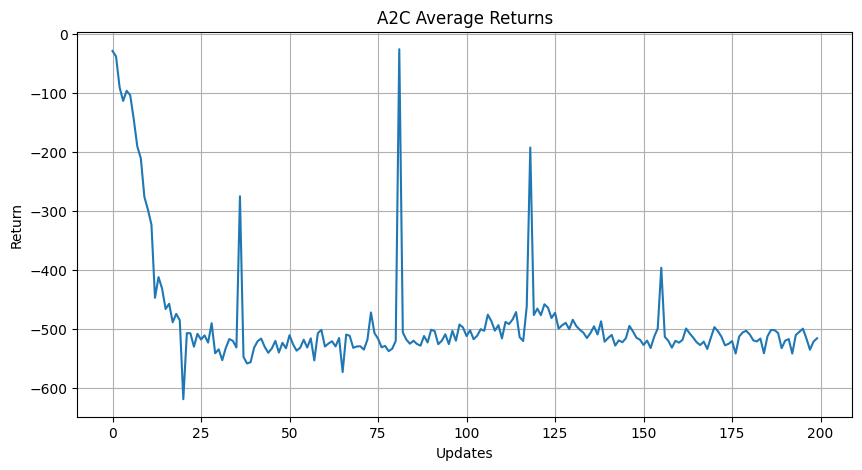

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [7]:
# 학습 곡선 (Average Return)
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("A2C Average Returns")
plt.xlabel("Updates")
plt.ylabel("Return")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("a2c")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")